# Blur vs Sharp Image Classification using Handcrafted Features and MLP

This project aims to classify images into two classes: **Blurred** and **Sharp** using a traditional neural network (MLP) with handcrafted image features instead of raw image pixels.

## Hala E.H Alrantisi  ,     220223076
## Faten j. Safi       ,     220225172

## Problem Description

The goal of this project is to build a binary image classification system that determines whether an input image is:

- **Blurred**
- **Sharp**

Instead of using CNNs and raw image pixels, this project uses handcrafted features that capture blur-related information from the spatial, frequency, and structural domains, then feeds these features into an MLP classifier.

In [1]:
# Import libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.measure import shannon_entropy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Dataset Description

The original dataset contains three folders:

- `sharp`
- `defocused_blurred`
- `motion_blurred`

Since the project requires binary classification, the two blurred categories were merged into one class called **blur**, while the `sharp` folder represents the **sharp** class.

In [2]:
# Dataset paths
base_path = '/kaggle/input/datasets/kwentar/blur-dataset'

sharp_path = os.path.join(base_path, 'sharp')
defocus_path = os.path.join(base_path, 'defocused_blurred')
motion_path = os.path.join(base_path, 'motion_blurred')

## Checking the Original Image Size

Before feature extraction, I checked the original image resolution.

In [3]:
sample_img_path = os.path.join(sharp_path, os.listdir(sharp_path)[0])
sample_img = cv2.imread(sample_img_path)

print("Original image size:", sample_img.shape)

Original image size: (2048, 1536, 3)


The original image size was:

**(2048, 1536, 3)**

This means the original images had a very high resolution (**2048×1536**), which made feature extraction slow, especially for FFT and morphological operations.

## Image Resizing

To reduce computational cost and speed up feature extraction, all images were resized to **200×200** before computing the handcrafted features.

This reduced the computational load significantly while still preserving the important structural information needed for blur detection.

## Initial Feature Exploration

Before building the final model, I tested several handcrafted features individually to understand how well each one separates blurred and sharp images.

In [4]:
# Testing Laplacian variance on one sharp image
img_name = os.listdir(sharp_path)[0]
img_path = os.path.join(sharp_path, img_name)

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

lap = cv2.Laplacian(gray, cv2.CV_64F)
lap_var = lap.var()

print("Laplacian Variance:", lap_var)

# Testing Laplacian variance on one blurred image
img_name = os.listdir(motion_path)[0]
img_path = os.path.join(motion_path, img_name)

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

lap = cv2.Laplacian(gray, cv2.CV_64F)
lap_var = lap.var()

print("Laplacian Variance:", lap_var)

Laplacian Variance: 303.0216979274191
Laplacian Variance: 98.36657687632136


A blurred image produced a Laplacian variance close to:

**98.36**

This confirmed that Laplacian variance is a useful feature for blur detection.

### Experiment 2: Sobel Gradient on a Single Image

Sobel gradient was tested as an edge-based feature to measure average edge strength.

In [5]:
# Sobel feature on one image
img_name = os.listdir(sharp_path)[0]
img_path = os.path.join(sharp_path, img_name)

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(sobelx**2 + sobely**2)
sobel_feature = magnitude.mean()

print("Sobel feature sharp:", sobel_feature)
# Sobel feature on one image
img_name = os.listdir(motion_path)[0]
img_path = os.path.join(motion_path, img_name)

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(sobelx**2 + sobely**2)
sobel_feature = magnitude.mean()

print("Sobel feature blur:", sobel_feature)

Sobel feature sharp: 32.60972699348034
Sobel feature blur: 12.20058162057363


The Sobel feature was useful, but by itself it did not separate the two classes as strongly as Laplacian variance. It still provided complementary edge information when combined with other features.

### Experiment 3: Entropy on a Single Image

Entropy was tested as a texture and information-content feature.

In [6]:
def test_entropy_feature(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    entropy = shannon_entropy(gray)
    return entropy

sharp_img = os.path.join(sharp_path, os.listdir(sharp_path)[0])
blur_img = os.path.join(motion_path, os.listdir(motion_path)[0])

print("Sharp Entropy:", test_entropy_feature(sharp_img))
print("Blur Entropy:", test_entropy_feature(blur_img))

Sharp Entropy: 6.812305105047142
Blur Entropy: 6.03481337629611


The entropy values were:

- **Sharp Entropy: 6.81**
- **Blur Entropy: 6.03**

This indicates that sharp images contain richer texture and more information than blurred images.

### Feature Sets Tested

The following handcrafted features were explored during the experiments:

1. **Laplacian variance**
2. **Sobel mean gradient**
3. **Edge density**
4. **High-frequency FFT energy**
5. **Opening difference**
6. **Entropy**
7. **Intensity variance** (tested but not kept in final model)
8. **Gradient variance** (tested but not kept in final model)

## Important Implementation Notes

### FFT Feature Issue
A first raw FFT-based feature was tested, but it significantly reduced performance (accuracy dropped to about **36%**). This happened because the FFT values were unstable in raw form.

To fix this, the FFT feature was reformulated using:

- **log magnitude spectrum**
- averaging only the **high-frequency region outside the center**

This improved its stability and raised model performance significantly.

### Runtime Issue
Feature extraction was slow because the original image resolution was large (**2048×1536**). To solve this, all images were resized to **200×200**, which made feature extraction much faster without harming performance.

In [7]:
# Final feature extraction function
def extract_features(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize image to speed up computation
    gray = cv2.resize(gray, (200, 200))

    # 1) Laplacian variance
    lap = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 2) Sobel mean gradient
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    sobel_feature = magnitude.mean()

    # 3) Edge density
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # 4) High-frequency FFT energy
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.log(1 + np.abs(fshift))

    rows, cols = gray.shape
    crow, ccol = rows // 2, cols // 2

    mask = np.ones((rows, cols), dtype=np.uint8)
    r = 20
    mask[crow-r:crow+r, ccol-r:ccol+r] = 0

    high_freq_energy = np.mean(magnitude_spectrum[mask == 1])


    # 5) Entropy
    entropy = shannon_entropy(gray)
    
    # 6) Opening difference
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    diff = cv2.absdiff(gray, opened)
    opening_diff = np.mean(diff)

    return [
        lap,
        sobel_feature,
        edge_density,
        high_freq_energy,
        entropy,
        opening_diff
    ]

## Building the Dataset

Each image is converted into a feature vector.  
Labels were assigned as follows:

- **1 = sharp**
- **0 = blur**

In [8]:
X = []
y = []

# Sharp images
for img_name in os.listdir(sharp_path):
    img_path = os.path.join(sharp_path, img_name)
    X.append(extract_features(img_path))
    y.append(1)

# Defocused blur images
for img_name in os.listdir(defocus_path):
    img_path = os.path.join(defocus_path, img_name)
    X.append(extract_features(img_path))
    y.append(0)

# Motion blur images
for img_name in os.listdir(motion_path):
    img_path = os.path.join(motion_path, img_name)
    X.append(extract_features(img_path))
    y.append(0)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Sharp images:", np.sum(y == 1))
print("Blur images:", np.sum(y == 0))

Dataset shape: (1050, 6)
Labels shape: (1050,)
Sharp images: 350
Blur images: 700


The final dataset contains:

- **350 sharp images**
- **700 blurred images**
- Total: **1050 images**

## Data Splitting and Normalization

The dataset was split into:

- **80% training**
- **20% testing**

Then the features were standardized using **StandardScaler** before training the MLP classifier.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## MLP Model Architecture

The classifier is implemented using a **Multilayer Perceptron (MLP)**.

- Input layer: receives the handcrafted feature vector
- Hidden layers: two fully connected layers with **ReLU**
- Output: binary classification (**blur / sharp**)
- Optimizer: **Adam**

In [10]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

In [11]:
model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=42)

## Final Evaluation

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9571428571428572

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       134
           1       0.97      0.91      0.94        76

    accuracy                           0.96       210
   macro avg       0.96      0.95      0.95       210
weighted avg       0.96      0.96      0.96       210



## Incremental Feature Improvements

The model was improved gradually by adding handcrafted features step by step and evaluating their effect on classification performance.

### Laplacian Variance (Baseline)
The initial model used **Laplacian variance** as a sharpness indicator.  
This feature measures the intensity variation in the image and is commonly used to detect blur.

The model achieved an accuracy of approximately **83%** using only this feature.

### Adding Sobel Gradient
After adding the **Sobel mean gradient** feature, the model accuracy improved from approximately **83% to about 85%**.  
This indicates that combining multiple edge-based features helps the neural network better distinguish between blurred and sharp images.

### Adding Edge Density
Next, **edge density** was added as a third feature.  
The classification accuracy improved further to approximately **90%**, confirming that combining different edge-related measurements improves the ability to capture blur characteristics.

### Adding FFT High-Frequency Feature
I first tested a raw FFT-based feature, but it caused poor classification performance because the values were unstable and difficult for the model to interpret. The accuracy dropped significantly to about **36%**.

To fix this issue, the FFT feature was refined by computing the **log magnitude spectrum** and averaging only the **high-frequency region outside the center** of the frequency domain.

After this modification, the FFT feature became much more useful and the model accuracy increased to approximately **93%**.

### Adding Entropy
A **entropy** feature was added as a texture-based feature. 
Entropy measures the amount of information and complexity in the image. Sharp images typically contain richer textures and therefore higher entropy values compared to blurred images,the model accuracy increased to approximately **94%**..


### Adding Opening difference
Finally, **opening_diff** which measures the change between the original image and the image after morphological opening. 

This feature captures the amount of fine details removed by the opening operation. Since sharp images contain more small structures and edges, they produce larger differences compared to blurred images. 

After adding this feature, the model achieved the best performance with an accuracy of approximately **95.71%**.

## Image Resolution Experiment

The original dataset images had a resolution of **2048×1536 pixels**, which made feature extraction computationally expensive.

To improve efficiency, images were resized before feature extraction.  
Two resolutions were tested:

- **500×500 → Accuracy ≈ 94.76%**
- **200×200 → Accuracy ≈ 95.71%**

Interestingly, the smaller resolution slightly improved performance while also reducing computation time.  
Therefore, **200×200 was selected as the final preprocessing resolution**.

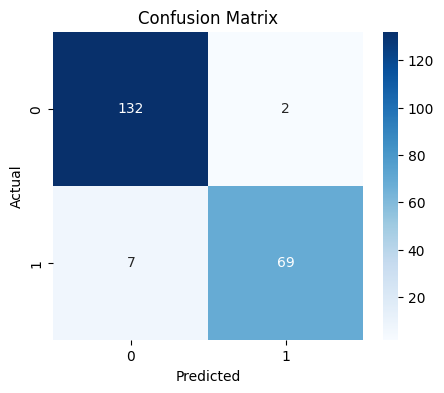

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Analysis

The confusion matrix shows how the model performed on the test set.

- **132 blurred images** were correctly classified as blur.
- **69 sharp images** were correctly classified as sharp.
- **2 blurred images** were incorrectly predicted as sharp.
- **7 sharp images** were incorrectly predicted as blur.

Overall, only **9 images out of 210** were misclassified, which corresponds to an accuracy of approximately **95.23%**.

The results indicate that the model is highly effective at distinguishing blurred images from sharp ones, with very few classification errors.

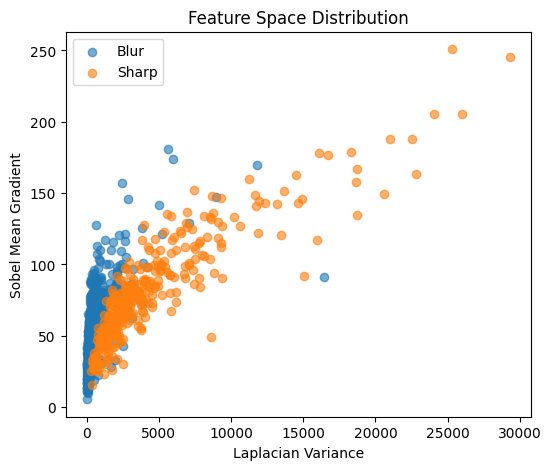

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Blur", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Sharp", alpha=0.6)

plt.xlabel("Laplacian Variance")
plt.ylabel("Sobel Mean Gradient")
plt.title("Feature Space Distribution")
plt.legend()
plt.show()

## Feature Space Visualization

The scatter plot above shows the distribution of images in the feature space using two of the extracted features:

- **Laplacian Variance**
- **Sobel Mean Gradient**

Blurred images tend to cluster in the lower region of the plot because they contain weaker edges and lower intensity variations. In contrast, sharp images generally appear in higher regions of the feature space due to stronger edges and richer image details.

Although there is some overlap between the two classes, the general separation between blurred and sharp images indicates that these handcrafted features provide useful information for classification.

This visualization helps explain why the neural network classifier achieves a high accuracy of approximately **95%**.

In [15]:


def opening_difference_feature(img_path):

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # structuring element
    kernel = np.ones((5,5), np.uint8)

    # morphological opening
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)

    # difference
    diff = cv2.absdiff(gray, opened)

    # feature value
    feature = np.mean(diff)

    return feature
sharp_image_path = os.path.join(sharp_path, os.listdir(sharp_path)[1])
blur_image_path = os.path.join(motion_path, os.listdir(motion_path)[0])

In [16]:
sharp = opening_difference_feature(sharp_image_path)
blur = opening_difference_feature(blur_image_path)

print("Sharp Opening Difference:", sharp)
print("Blur Opening Difference:", blur)

Sharp Opening Difference: 15.281412044986263
Blur Opening Difference: 3.0459177541208793


# Test model 

In [17]:
import os
print(os.listdir('/kaggle/input/datasets/halaessamalrantisi/dataset'))


['IMG-20230110-WA0019.jpg', 'download (2).jpeg']


In [18]:
def predict_image(img_path):
    
    features = extract_features(img_path)
    features = np.array(features).reshape(1, -1)
    features = scaler.transform(features)
    
    prediction = model.predict(features)[0]
    
    if prediction == 1:
        print("Prediction: Sharp Image ✅")
    else:
        print("Prediction: Blurred Image ❌")
    
    return prediction


Prediction: Sharp Image ✅


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


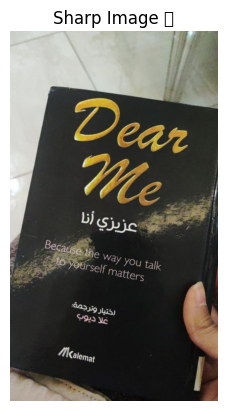

Prediction: Blurred Image ❌


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


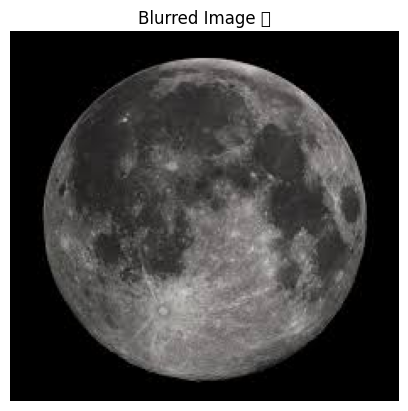

In [19]:
def show_and_predict(img_path) :
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis('off')

    prediction = predict_image(img_path)

    if prediction == 1:
        plt.title("Sharp Image ✅")
    else:
        plt.title("Blurred Image ❌")

    plt.show()
test1 = '/kaggle/input/datasets/halaessamalrantisi/dataset/IMG-20230110-WA0019.jpg'
test2 = '/kaggle/input/datasets/halaessamalrantisi/dataset/download (2).jpeg'


show_and_predict(test1)
show_and_predict(test2)
